In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
np.random.seed(123)

In [11]:
df_fraud_detection = pd.read_csv("Fraud Detection Dataset.csv")

In [12]:
df_fraud_detection.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [14]:
df_fraud_detection.nunique()

Transaction_ID                      50000
User_ID                              4000
Transaction_Amount                  44821
Transaction_Type                        5
Time_of_Transaction                    24
Device_Used                             4
Location                                8
Previous_Fraudulent_Transactions        5
Account_Age                           119
Number_of_Transactions_Last_24H        14
Payment_Method                          5
Fraudulent                              2
dtype: int64

Ce dataset comporte des informations sur les transactions de 4000 utilisateurs différents sur une période de 24h. 

In [22]:
# Part de valeurs manquantes dans le dataset
df_fraud_detection.isna().sum()/df_fraud_detection['User_ID'].count()*100

Transaction_ID                      0.000000
User_ID                             0.000000
Transaction_Amount                  4.941176
Transaction_Type                    0.000000
Time_of_Transaction                 5.003922
Device_Used                         4.849020
Location                            4.994118
Previous_Fraudulent_Transactions    0.000000
Account_Age                         0.000000
Number_of_Transactions_Last_24H     0.000000
Payment_Method                      4.841176
Fraudulent                          0.000000
dtype: float64

Quelques mesures statistiques sur les différentes variables présentes : 

In [23]:
df_fraud_detection.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [27]:
df_fraud_detection['Fraudulent'].value_counts()/df_fraud_detection['User_ID'].count()*100

Fraudulent
0    95.078431
1     4.921569
Name: count, dtype: float64

Le déséquilibre de classes est plutôt clair ici avec des transactions licites qui représentent 95,1% des données tandis que les transactions frauduleuses n'en représentent que 4.9%. 

Intéressons nous plus en détail aux transactions frauduleuses. 


In [28]:
df_fraudulent=df_fraud_detection[df_fraud_detection['Fraudulent']==1]

In [29]:
df_fraudulent.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
6,T7,4772,544.81,Bill Payment,2.0,Tablet,Boston,3,6,9,UPI,1
27,T28,3433,4519.04,Bill Payment,13.0,Tablet,Boston,0,81,10,Credit Card,1
43,T44,3047,4413.05,Bank Transfer,21.0,Desktop,Boston,4,46,11,Credit Card,1
68,T69,3363,3517.65,Bill Payment,0.0,Desktop,Boston,2,29,8,UPI,1
73,T74,4417,1440.79,Online Purchase,15.0,Tablet,Miami,2,16,1,Net Banking,1


In [31]:
df_fraudulent.nunique()

Transaction_ID                      2460
User_ID                             1857
Transaction_Amount                  2301
Transaction_Type                       5
Time_of_Transaction                   24
Device_Used                            4
Location                               8
Previous_Fraudulent_Transactions       5
Account_Age                          119
Number_of_Transactions_Last_24H       14
Payment_Method                         5
Fraudulent                             1
dtype: int64

In [32]:
df_fraudulent.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,2510.000000,2385.000000,2376.000000,2510.000000,2510.000000,2510.000000,2510.0
mean,3045.889243,3118.367245,11.702862,2.002789,60.971315,7.427092,1.0
std,1154.536265,5654.749402,6.978409,1.402466,34.591645,4.002100,0.0
min,1001.000000,14.310000,0.000000,0.000000,1.000000,1.000000,1.0
25%,2080.000000,1222.260000,6.000000,1.000000,32.000000,4.000000,1.0
50%,3022.500000,2516.010000,12.000000,2.000000,62.000000,7.000000,1.0
75%,4060.500000,3738.620000,18.000000,3.000000,91.000000,11.000000,1.0
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.0


Il semblerait que les mesures statistiques sur les transactions frauduleuses donnent des résultats assez proches des mesures obtenues sur l'ensemble des transactions. 

Regardons si parmi les transactions frauduleuses il n'existe pas d'autres déséquilibres de classes.

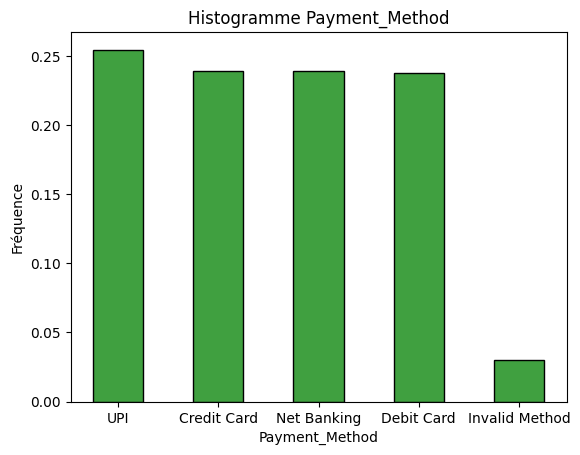

In [49]:
sns.histplot(df_fraudulent['Payment_Method'], stat='density',color = 'green',element='bars',shrink=0.5)
plt.title('Histogramme Payment_Method')
plt.xlabel('Payment_Method')
plt.ylabel('Fréquence')
plt.show()

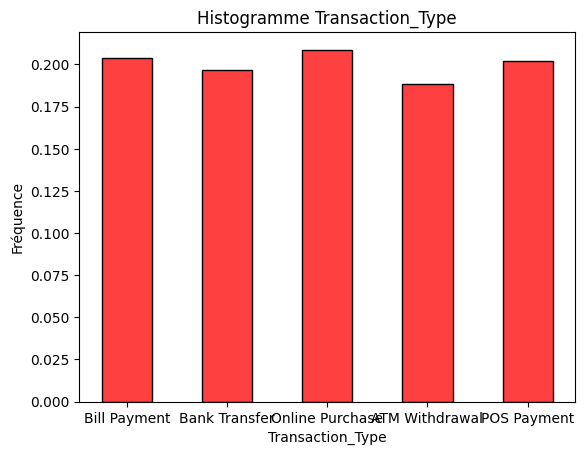

In [50]:
sns.histplot(df_fraudulent['Transaction_Type'], stat='density',color = 'red',shrink=0.5)
plt.title('Histogramme Transaction_Type')
plt.xlabel('Transaction_Type')
plt.ylabel('Fréquence')
plt.show()

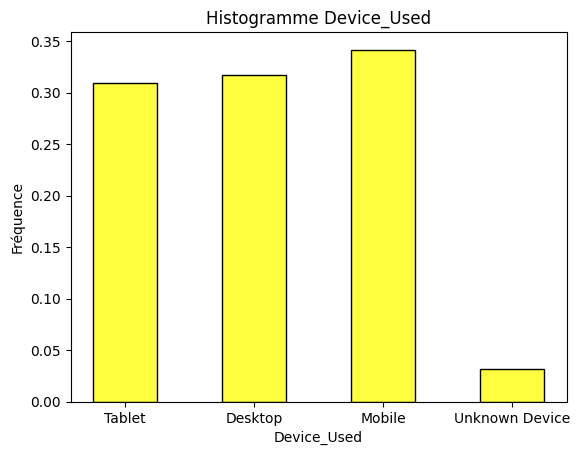

In [51]:
sns.histplot(df_fraudulent['Device_Used'], stat='density',color = 'yellow',shrink=0.5)
plt.title('Histogramme Device_Used')
plt.xlabel('Device_Used')
plt.ylabel('Fréquence')
plt.show()

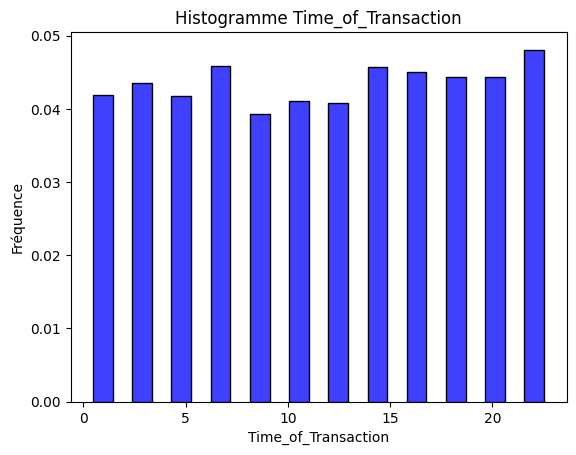

In [53]:
sns.histplot(df_fraudulent['Time_of_Transaction'], bins=12, stat='density',color = 'blue',element='bars',shrink=0.5)
plt.title('Histogramme Time_of_Transaction')
plt.xlabel('Time_of_Transaction')
plt.ylabel('Fréquence')
plt.show()

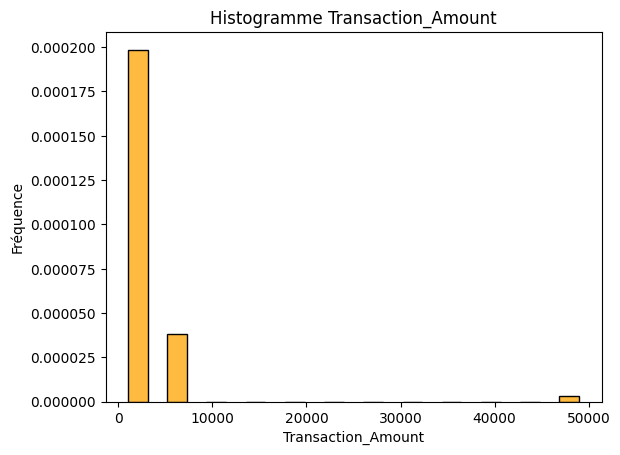

In [54]:
sns.histplot(df_fraudulent['Transaction_Amount'], bins=12, stat='density',color = 'orange',element='bars',shrink=0.5)
plt.title('Histogramme Transaction_Amount')
plt.xlabel('Transaction_Amount')
plt.ylabel('Fréquence')
plt.show()

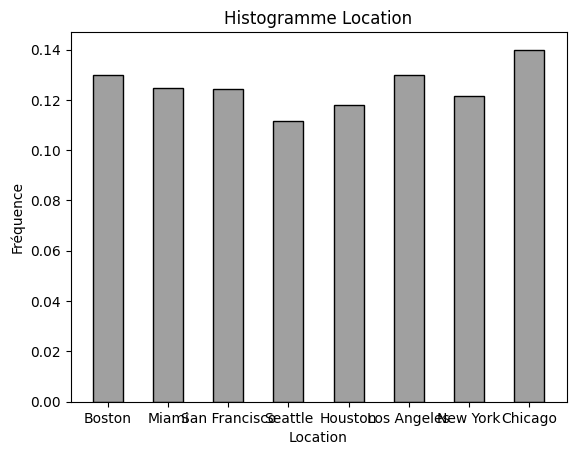

In [56]:
sns.histplot(df_fraudulent['Location'], stat='density',color = 'grey',element='bars',shrink=0.5)
plt.title('Histogramme Location')
plt.xlabel('Location')
plt.ylabel('Fréquence')
plt.show()